# DigitVision AI
## Intelligent Handwritten Digit Recognition using Artificial Neural Networks (ANN)

### Minor AI/ML Project

**Developed By:** Mansi Muneshwar



---

## Project Overview

DigitVision AI is a deep learning-based handwritten digit recognition system that classifies handwritten digits (0–9) using an Artificial Neural Network (ANN). The project uses the MNIST dataset provided by TensorFlow/Keras and demonstrates the complete machine learning workflow including data exploration, preprocessing, model development, evaluation, visualization, and deployment through an interactive Streamlit application.

---

## Project Objectives

- Load and analyze the MNIST handwritten digit dataset.
- Explore and visualize the dataset.
- Preprocess the images for ANN training.
- Build and train an Artificial Neural Network.
- Evaluate the trained model using multiple metrics.
- Visualize predictions and model performance.
- Save all generated figures, outputs, and trained models.
- Build an interactive Streamlit application for handwritten digit prediction.

---

**Project Version:** 1.0

Import Required Libraries

In [1]:
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
warnings.filterwarnings("ignore")

print("✅ All required libraries imported successfully.")

✅ All required libraries imported successfully.


Check TensorFlow & GPU

In [2]:
print("=" * 70)
print("DigitVision AI - Runtime Environment")
print("=" * 70)

print(f"TensorFlow Version : {tf.__version__}")
print(f"NumPy Version      : {np.__version__}")

gpu = tf.config.list_physical_devices('GPU')

if gpu:
    print("\n✅ GPU Detected")
    print(gpu)
else:
    print("\n⚠️ GPU Not Detected")
    print("Training will run on CPU.")

print("=" * 70)

DigitVision AI - Runtime Environment
TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2

✅ GPU Detected
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Create Project Folder Structure

In [3]:
PROJECT_NAME = "DigitVision_AI"

FOLDERS = [
    "dataset",
    "figures",
    "models",
    "outputs",
    "report",
    "app",
    "checkpoints"
]

os.makedirs(PROJECT_NAME, exist_ok=True)

for folder in FOLDERS:
    os.makedirs(os.path.join(PROJECT_NAME, folder), exist_ok=True)

print("✅ Project folders created successfully.\n")

for folder in FOLDERS:
    print(f"📁 {PROJECT_NAME}/{folder}")

✅ Project folders created successfully.

📁 DigitVision_AI/dataset
📁 DigitVision_AI/figures
📁 DigitVision_AI/models
📁 DigitVision_AI/outputs
📁 DigitVision_AI/report
📁 DigitVision_AI/app
📁 DigitVision_AI/checkpoints


Define Project Paths

In [4]:
BASE_DIR = PROJECT_NAME

DATASET_DIR = os.path.join(BASE_DIR, "dataset")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")
MODELS_DIR = os.path.join(BASE_DIR, "models")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
REPORT_DIR = os.path.join(BASE_DIR, "report")
APP_DIR = os.path.join(BASE_DIR, "app")
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")

print("✅ Project paths initialized successfully.")

✅ Project paths initialized successfully.


Set Random Seed

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"✅ Random seed set to {SEED}.")

✅ Random seed set to 42.


Helper Function to Save Figures

In [6]:
def save_figure(file_name, dpi=300):
    """
    Save the current matplotlib figure to the figures folder.

    Parameters:
        file_name (str): Name of the output image file.
        dpi (int): Resolution of the saved figure.
    """

    save_path = os.path.join(FIGURES_DIR, file_name)

    plt.savefig(
        save_path,
        dpi=dpi,
        bbox_inches="tight"
    )

    print(f"✅ Figure saved successfully:")
    print(save_path)

# 1. Loading the MNIST Dataset

In this section, we load the MNIST handwritten digit dataset and examine its basic structure before performing exploratory data analysis.

Load the MNIST Dataset

In [7]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("MNIST dataset loaded successfully.\n")

print(f"Training Images : {X_train.shape}")
print(f"Training Labels : {y_train.shape}")

print()

print(f"Testing Images  : {X_test.shape}")
print(f"Testing Labels  : {y_test.shape}")

print()

print(f"Image Dimension : {X_train.shape[1]} × {X_train.shape[2]} pixels")
print(f"Number of Classes : {len(np.unique(y_train))}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST dataset loaded successfully.

Training Images : (60000, 28, 28)
Training Labels : (60000,)

Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)

Image Dimension : 28 × 28 pixels
Number of Classes : 10


Display Random Sample Images

✅ Figure saved successfully:
DigitVision_AI/figures/random_digit_samples.png


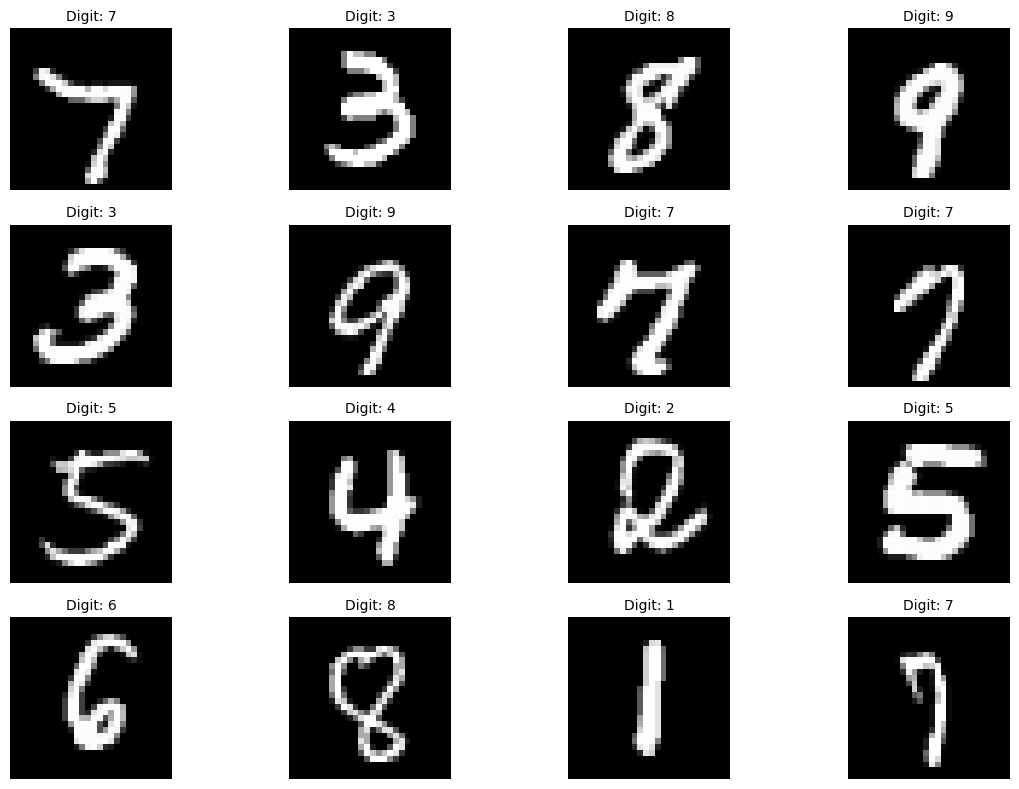

In [8]:
plt.figure(figsize=(12, 8))

random_indices = np.random.choice(len(X_train), 16, replace=False)

for i, index in enumerate(random_indices):

    plt.subplot(4, 4, i + 1)

    plt.imshow(X_train[index], cmap="gray")

    plt.title(f"Digit: {y_train[index]}", fontsize=10)

    plt.axis("off")

plt.tight_layout()

save_figure("random_digit_samples.png")

plt.show()

## Observation

- The dataset contains grayscale images of handwritten digits ranging from **0 to 9**.
- Each image has a resolution of **28 × 28 pixels**.
- The handwriting style varies considerably between samples, allowing the model to learn robust digit representations.
- These variations make the dataset suitable for evaluating the generalization capability of deep learning models.

# Class Distribution Analysis

Before training the neural network, it is important to examine how the handwritten digit samples are distributed across all classes. A balanced dataset ensures that the model learns each digit fairly without being biased toward any particular class.

Plot Class Distribution

✅ Figure saved successfully:
DigitVision_AI/figures/digit_class_distribution.png


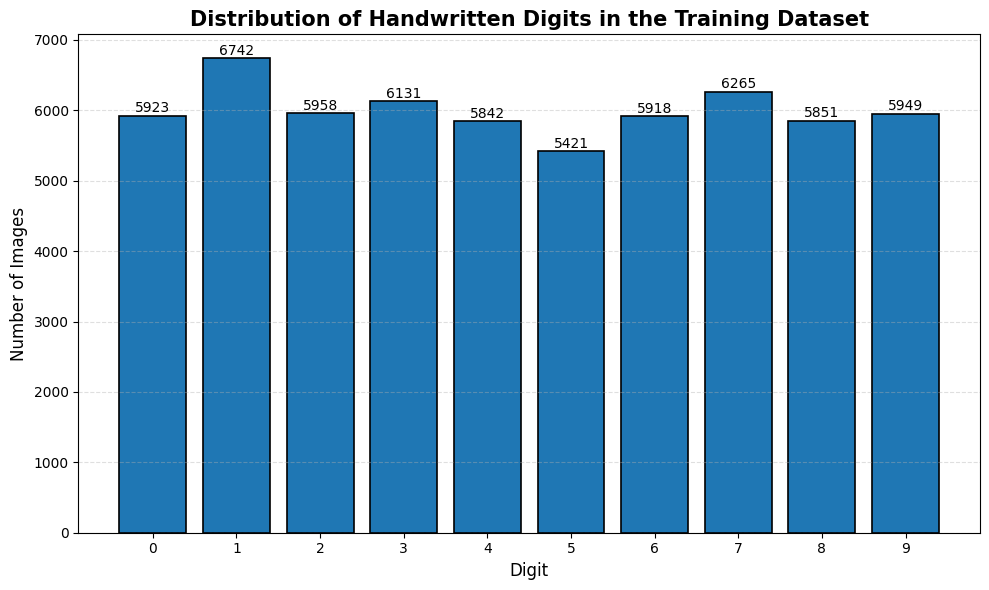

In [9]:
# Count the number of images belonging to each digit

digit_classes, digit_counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,6))

bars = plt.bar(
    digit_classes,
    digit_counts,
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Distribution of Handwritten Digits in the Training Dataset",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Digit", fontsize=12)

plt.ylabel("Number of Images", fontsize=12)

plt.xticks(digit_classes)

# Display count above each bar
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 50,
        f"{height}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

save_figure("digit_class_distribution.png")

plt.show()

## Observation

- The training dataset contains handwritten samples for all ten digit classes (0–9).
- The number of samples in each class is relatively balanced, with only minor variations.
- Since no class is significantly underrepresented, the dataset does not suffer from class imbalance.
- A balanced class distribution allows the neural network to learn all digit classes effectively without requiring additional balancing techniques.

# Pixel Intensity Distribution

Each pixel in the MNIST dataset has an intensity value ranging from **0 (black)** to **255 (white)**. Visualizing the pixel intensity distribution helps us understand the overall characteristics of the images and provides motivation for normalizing the pixel values before training the neural network.

Plot Pixel Intensity Distribution

✅ Figure saved successfully:
DigitVision_AI/figures/pixel_intensity_distribution.png


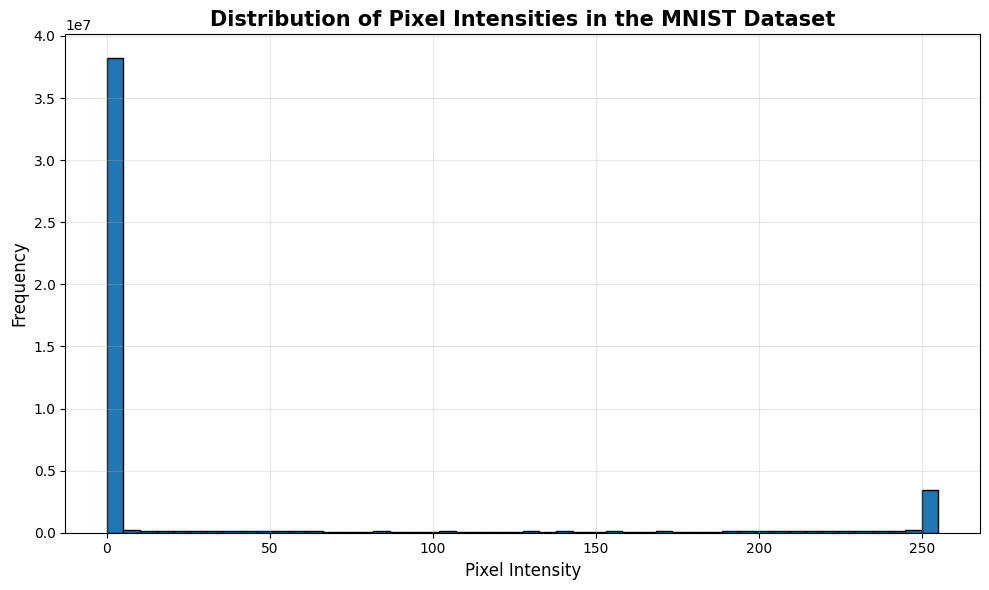

In [10]:
# Flatten all training images into a single array of pixel values
pixel_values = X_train.flatten()

plt.figure(figsize=(10, 6))

plt.hist(
    pixel_values,
    bins=50,
    edgecolor="black"
)

plt.title(
    "Distribution of Pixel Intensities in the MNIST Dataset",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Pixel Intensity", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

save_figure("pixel_intensity_distribution.png")

plt.show()

Normalize the Images

# Image Preprocessing

Before training the Artificial Neural Network (ANN), the pixel values are normalized from the range **0–255** to **0–1**. Normalization improves numerical stability, speeds up training, and helps the model converge more effectively.

In [11]:
# Normalize pixel values

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("✅ Images normalized successfully.\n")

print(f"Training Image Range : {X_train.min():.1f} to {X_train.max():.1f}")
print(f"Testing Image Range  : {X_test.min():.1f} to {X_test.max():.1f}")

✅ Images normalized successfully.

Training Image Range : 0.0 to 1.0
Testing Image Range  : 0.0 to 1.0


Flatten the Images

In [12]:
# Flatten images

X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

print("Training Shape :", X_train_flat.shape)
print("Testing Shape  :", X_test_flat.shape)

Training Shape : (60000, 784)
Testing Shape  : (10000, 784)


Verify the Processed Data

In [13]:
print("=" * 60)

print("Processed Dataset Summary")

print("=" * 60)

print(f"Training Images : {X_train_flat.shape}")
print(f"Testing Images  : {X_test_flat.shape}")

print()

print(f"Training Labels : {y_train.shape}")
print(f"Testing Labels  : {y_test.shape}")

print()

print(f"Input Features per Image : {X_train_flat.shape[1]}")

print("=" * 60)

Processed Dataset Summary
Training Images : (60000, 784)
Testing Images  : (10000, 784)

Training Labels : (60000,)
Testing Labels  : (10000,)

Input Features per Image : 784


Visualize a Normalized Image

✅ Figure saved successfully:
DigitVision_AI/figures/normalized_sample_image.png


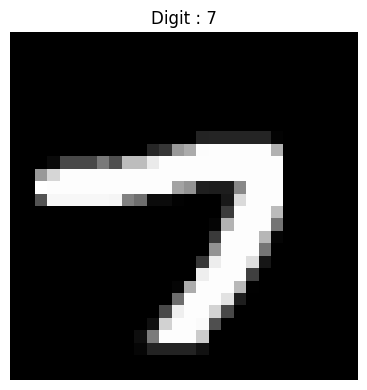

In [14]:
sample_index = np.random.randint(len(X_train))

plt.figure(figsize=(4, 4))

plt.imshow(X_train[sample_index], cmap="gray")

plt.title(f"Digit : {y_train[sample_index]}")

plt.axis("off")

plt.tight_layout()

save_figure("normalized_sample_image.png")

plt.show()

Data Ready for Model Training

## Data Preparation Complete

The dataset has now been successfully preprocessed.

The following steps have been completed:

- Pixel values normalized to the range **0–1**
- Images reshaped into **784-dimensional feature vectors**
- Training and testing datasets prepared for ANN model development

The data is now ready for building and training the Artificial Neural Network.

Create the ANN Model

In [15]:
model = keras.Sequential([

    layers.Input(shape=(784,), name="Input_Layer"),

    layers.Dense(
        256,
        activation="relu",
        name="Hidden_Layer_1"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        128,
        activation="relu",
        name="Hidden_Layer_2"
    ),

    layers.Dropout(0.2),

    layers.Dense(
        10,
        activation="softmax",
        name="Output_Layer"
    )

])

print("✅ ANN Model Created Successfully.")

✅ ANN Model Created Successfully.


Display Model Summary

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Compile the Model

In [17]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("✅ Model compiled successfully.")

✅ Model compiled successfully.


Configure Model Checkpoint

In [21]:
early_stopping = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1

)

checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "best_digitvision_model.keras"
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(

    filepath=checkpoint_path,

    monitor="val_accuracy",

    save_best_only=True,

    mode="max",

    verbose=1

)

print("✅ Training callbacks configured successfully.")

✅ Training callbacks configured successfully.


Train the ANN

# Training the Model

The Artificial Neural Network is trained using the training dataset while validating its performance on the testing dataset after each epoch. The best-performing model is automatically saved using ModelCheckpoint.

In [22]:
history = model.fit(

    X_train_flat,
    y_train,

    validation_data=(X_test_flat, y_test),

    epochs=20,

    batch_size=128,

    callbacks=[
        checkpoint_callback,
        early_stopping
    ],

    verbose=1

)

Epoch 1/20
458/469 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9902 - loss: 0.0292
Epoch 1: val_accuracy improved from None to 0.98400, saving model to DigitVision_AI/checkpoints/best_digitvision_model.keras

Epoch 1: finished saving model to DigitVision_AI/checkpoints/best_digitvision_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9891 - loss: 0.0315 - val_accuracy: 0.9840 - val_loss: 0.0602
Epoch 2/20
460/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9902 - loss: 0.0305
Epoch 2: val_accuracy did not improve from 0.98400
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9892 - loss: 0.0328 - val_accuracy: 0.9832 - val_loss: 0.0613
Epoch 3/20
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9903 - loss: 0.0292
Epoch 3: val_accuracy did not improve from 0.98400
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9895 - loss: 0.0313 - val_accuracy: 0.9839 - val_loss: 0.0614
Epoch 4/20
463/469 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9915 - 

Save the Final Model

In [23]:
model_path = os.path.join(
    MODELS_DIR,
    "digitvision_ann.keras"
)

model.save(model_path)

print("✅ Final ANN model saved successfully.")
print(f"\nModel Location:\n{model_path}")

✅ Final ANN model saved successfully.

Model Location:
DigitVision_AI/models/digitvision_ann.keras


Load the Best Saved Model

In [24]:
best_model = keras.models.load_model(checkpoint_path)

print("✅ Best model loaded successfully from checkpoint.")

✅ Best model loaded successfully from checkpoint.


Evaluate the Best Model

# Model Evaluation

The saved best-performing model is evaluated on the unseen testing dataset to measure its overall classification performance.

Test Accuracy & Loss

In [25]:
test_loss, test_accuracy = best_model.evaluate(
    X_test_flat,
    y_test,
    verbose=0
)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

print("=" * 50)

MODEL PERFORMANCE
Test Accuracy : 98.40%
Test Loss     : 0.0602


Generate Predictions

In [26]:
predictions = best_model.predict(
    X_test_flat,
    verbose=0
)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

print("✅ Predictions generated successfully.")

✅ Predictions generated successfully.


# Training Performance

The following visualizations illustrate how the model's accuracy and loss changed throughout the training process. These curves help assess the learning behavior of the neural network and identify signs of convergence or overfitting.

Plot Training & Validation Accuracy

✅ Figure saved successfully:
DigitVision_AI/figures/training_validation_accuracy.png


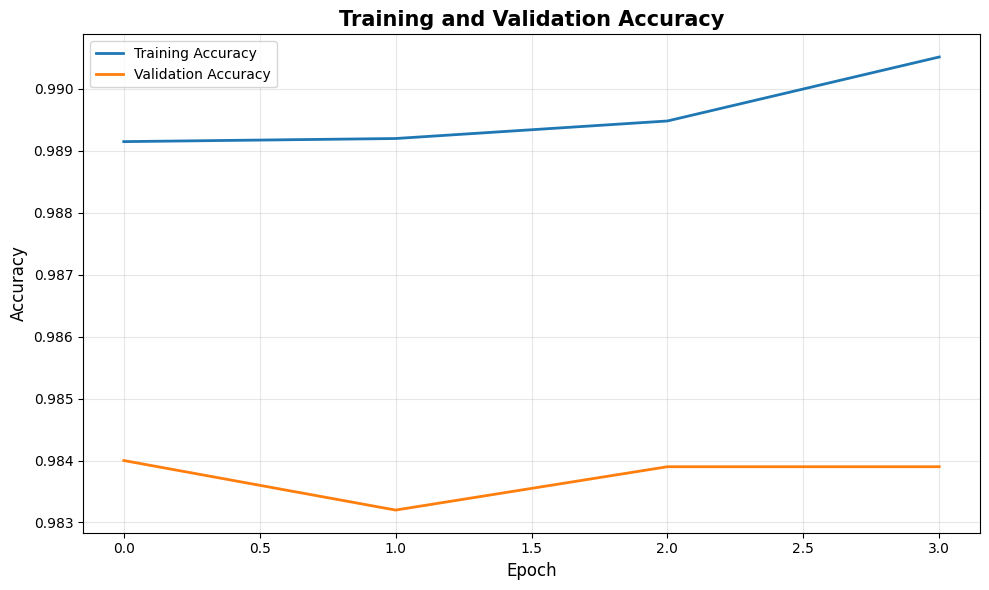

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    "Training and Validation Accuracy",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

save_figure("training_validation_accuracy.png")

plt.show()

Plot Training & Validation Loss

✅ Figure saved successfully:
DigitVision_AI/figures/training_validation_loss.png


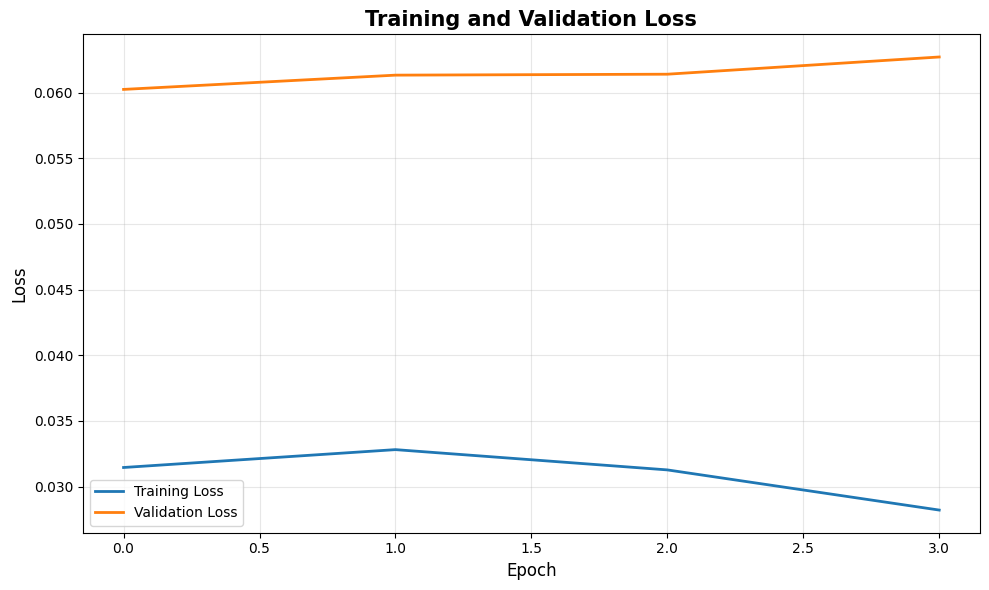

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

save_figure("training_validation_loss.png")

plt.show()

# Confusion Matrix

The confusion matrix provides a detailed view of the model's classification performance by comparing the actual digit labels with the predicted labels for the testing dataset.

✅ Figure saved successfully:
DigitVision_AI/figures/confusion_matrix.png


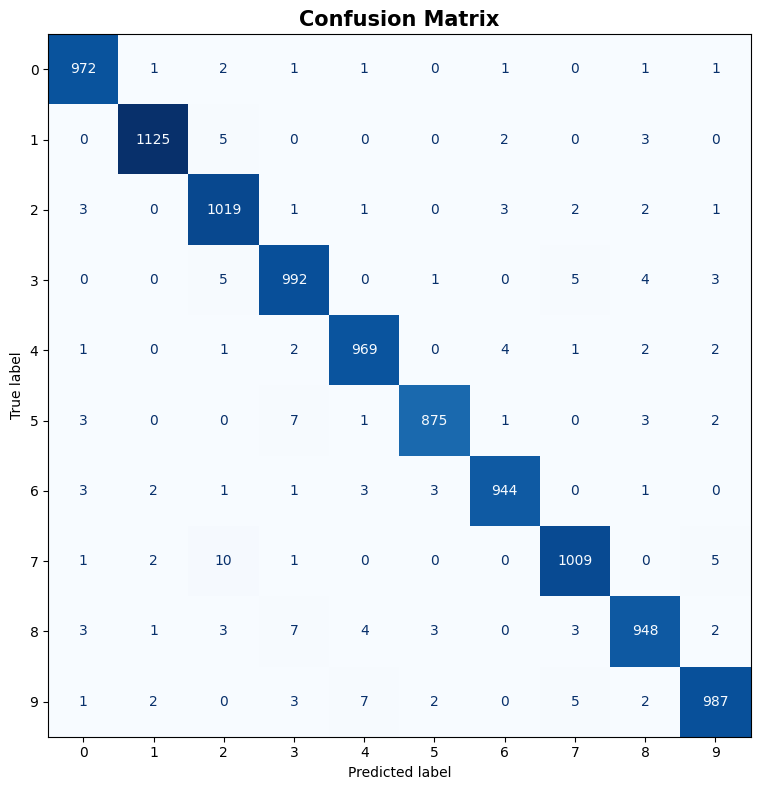

In [29]:
cm = confusion_matrix(
    y_test,
    predicted_labels
)

plt.figure(figsize=(9, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

display.plot(
    cmap="Blues",
    values_format="d",
    ax=plt.gca(),
    colorbar=False
)

plt.title(
    "Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

save_figure("confusion_matrix.png")

plt.show()

Generate Classification Report

In [30]:
report = classification_report(
    y_test,
    predicted_labels,
    digits=4
)

print(report)

report_path = os.path.join(
    OUTPUTS_DIR,
    "classification_report.txt"
)

with open(report_path, "w") as file:
    file.write(report)

print("\n✅ Classification report saved successfully.")

              precision    recall  f1-score   support

           0     0.9848    0.9918    0.9883       980
           1     0.9929    0.9912    0.9921      1135
           2     0.9742    0.9874    0.9808      1032
           3     0.9773    0.9822    0.9798      1010
           4     0.9828    0.9868    0.9848       982
           5     0.9898    0.9809    0.9854       892
           6     0.9885    0.9854    0.9869       958
           7     0.9844    0.9815    0.9830      1028
           8     0.9814    0.9733    0.9773       974
           9     0.9840    0.9782    0.9811      1009

    accuracy                         0.9840     10000
   macro avg     0.9840    0.9839    0.9839     10000
weighted avg     0.9840    0.9840    0.9840     10000


✅ Classification report saved successfully.


# Prediction Showcase

The following visualization displays randomly selected handwritten digit images from the testing dataset along with their actual labels, predicted labels, and prediction confidence. Correct predictions are displayed in green, while incorrect predictions are displayed in red.

Display Random Predictions with Confidence

✅ Figure saved successfully:
DigitVision_AI/figures/prediction_showcase.png


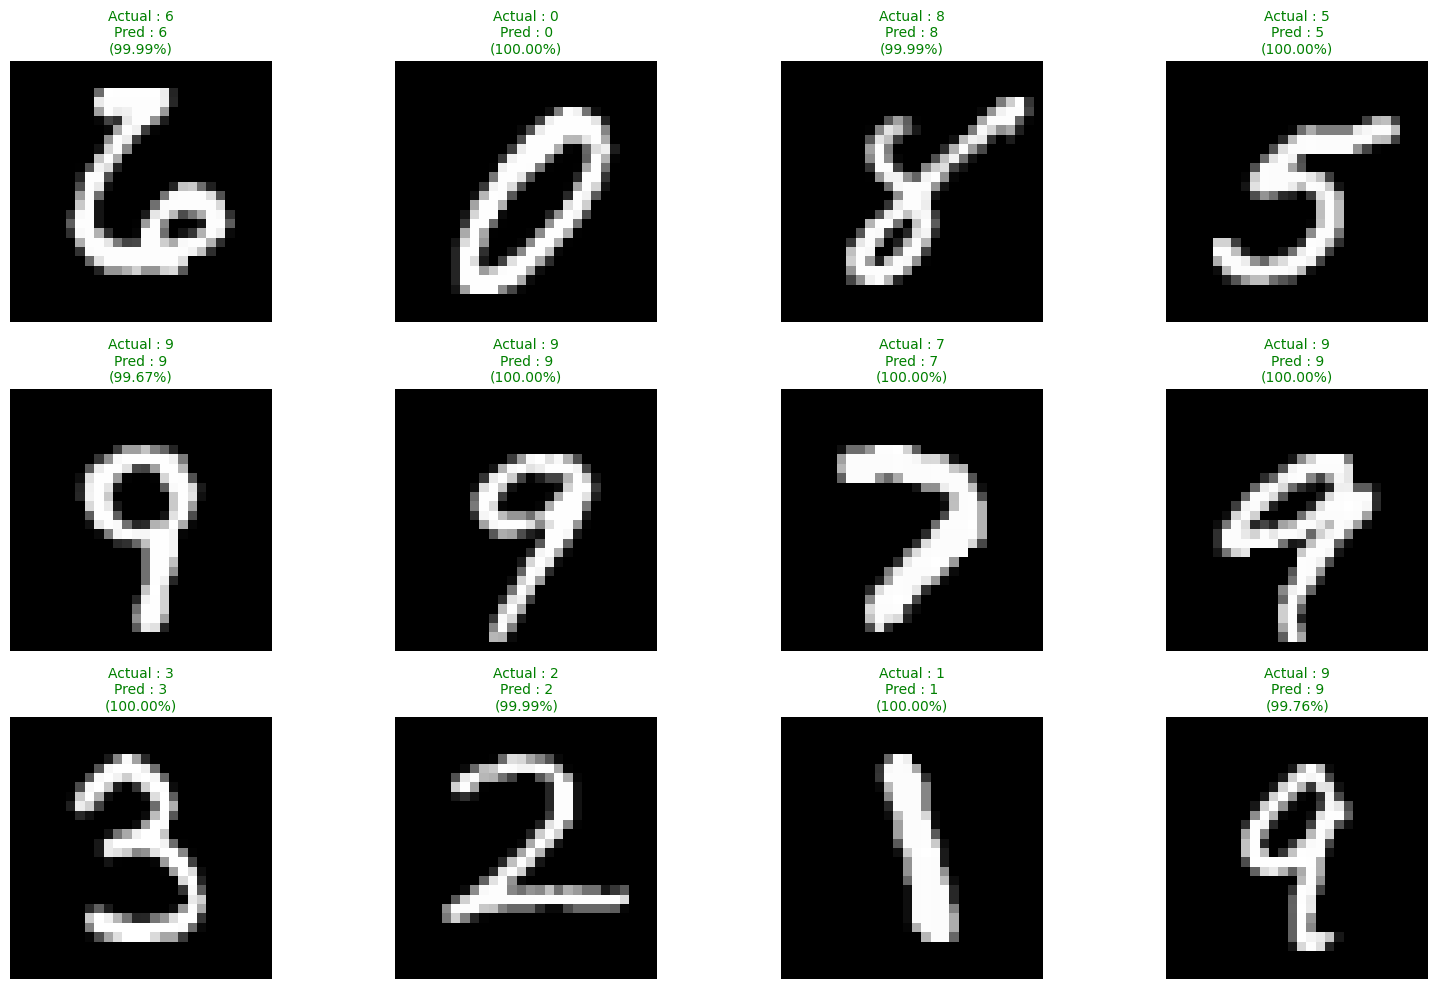

In [31]:
plt.figure(figsize=(16, 10))

random_indices = np.random.choice(len(X_test), 12, replace=False)

for i, index in enumerate(random_indices):

    plt.subplot(3, 4, i + 1)

    image = X_test[index]

    prediction = best_model.predict(
        image.reshape(1, 784),
        verbose=0
    )

    predicted_digit = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    actual_digit = y_test[index]

    color = "green" if predicted_digit == actual_digit else "red"

    plt.imshow(image, cmap="gray")

    plt.title(
        f"Actual : {actual_digit}\nPred : {predicted_digit}\n({confidence:.2f}%)",
        fontsize=10,
        color=color
    )

    plt.axis("off")

plt.tight_layout()

save_figure("prediction_showcase.png")

plt.show()

# Misclassified Predictions

Analyzing incorrectly classified samples helps identify challenging handwriting patterns and provides insights into the limitations of the trained model.

Show Misclassified Digits

In [32]:
misclassified = np.where(predicted_labels != y_test)[0]

print(f"Total Misclassified Images : {len(misclassified)}")

Total Misclassified Images : 160


Visualize Misclassified Samples

✅ Figure saved successfully:
DigitVision_AI/figures/misclassified_digits.png


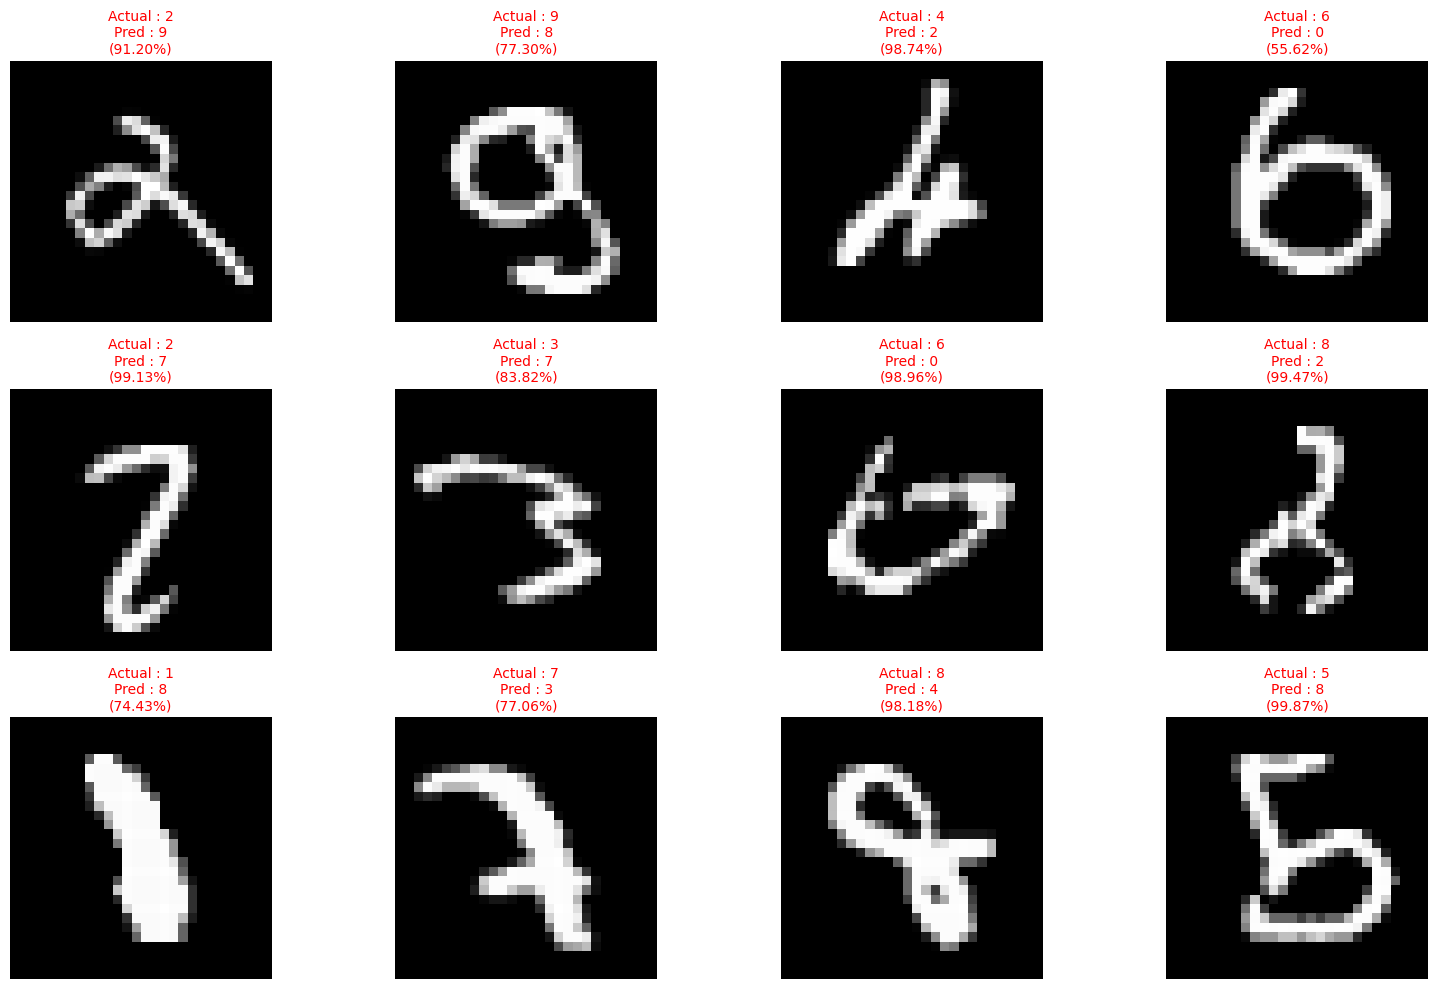

In [33]:
plt.figure(figsize=(16, 10))

for i in range(12):

    index = misclassified[i]

    prediction = best_model.predict(
        X_test[index].reshape(1, 784),
        verbose=0
    )

    confidence = np.max(prediction) * 100

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[index],
        cmap="gray"
    )

    plt.title(
        f"Actual : {y_test[index]}\nPred : {predicted_labels[index]}\n({confidence:.2f}%)",
        color="red",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()

save_figure("misclassified_digits.png")

plt.show()

Save Model Summary

In [34]:
summary_path = os.path.join(
    OUTPUTS_DIR,
    "model_summary.txt"
)

with open(summary_path, "w") as file:

    model.summary(
        print_fn=lambda x: file.write(x + "\n")
    )

print("✅ Model summary saved successfully.")

✅ Model summary saved successfully.


Save Evaluation Metrics

In [35]:
metrics_path = os.path.join(
    OUTPUTS_DIR,
    "evaluation_metrics.txt"
)

with open(metrics_path, "w") as file:

    file.write("DigitVision AI - Model Evaluation\n")
    file.write("=" * 50 + "\n\n")

    file.write(f"Test Accuracy : {test_accuracy:.4f}\n")
    file.write(f"Test Loss     : {test_loss:.4f}\n")
    file.write(f"Training Accuracy : {history.history['accuracy'][-1]:.4f}\n")
    file.write(f"Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}\n")

print("✅ Evaluation metrics saved successfully.")

✅ Evaluation metrics saved successfully.


Save Predictions

In [36]:
import pandas as pd

prediction_df = pd.DataFrame({

    "Actual Label": y_test,

    "Predicted Label": predicted_labels,

    "Confidence (%)": np.max(predictions, axis=1) * 100

})

prediction_path = os.path.join(
    OUTPUTS_DIR,
    "predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

print("✅ Prediction results saved successfully.")

✅ Prediction results saved successfully.


Save the Trained Model for Streamlit

# Preparing the Model for Deployment

The best-performing model obtained during training is saved separately for deployment in the Streamlit application.

In [37]:
deployment_model_path = os.path.join(
    MODELS_DIR,
    "digitvision_streamlit.keras"
)

best_model.save(deployment_model_path)

print("✅ Deployment model saved successfully.")
print(deployment_model_path)

✅ Deployment model saved successfully.
DigitVision_AI/models/digitvision_streamlit.keras
